In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [20]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load Sales_Financial.csv using exact folder path
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/DataXLab_datasource/Superstore_Sales_Financial.csv')

# Verify the file loaded successfully
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2015-103800,03/01/2015,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,7,0.1,2.96064
1,CA-2015-112326,04/01/2015,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,4,0.0,0.70800
2,CA-2015-112326,04/01/2015,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,8,0.2,43.63776
3,CA-2015-112326,04/01/2015,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,5,0.0,2.35680
4,CA-2015-141817,05/01/2015,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,7,0.0,3.90720


In [21]:
# 1. High-level dataset summary
print("--- Data Info ---")
df.info()

# 2. Summary statistics for numerical features (mean, std, min, max, quartiles)
print("\n--- Numerical Summary ---")
display(df.describe().T)

# 3. Summary statistics for categorical features
print("\n--- Categorical Summary ---")
display(df.describe(include=['object','category']).T)

# 4. Check missing values and value counts for key categorical columns
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       9800 non-null   object 
 1   Order_Date     9800 non-null   object 
 2   Ship_Date      9800 non-null   object 
 3   Ship_Mode      9800 non-null   object 
 4   Customer_ID    9800 non-null   object 
 5   Customer_Name  9800 non-null   object 
 6   Segment        9800 non-null   object 
 7   Country        9800 non-null   object 
 8   City           9800 non-null   object 
 9   State          9800 non-null   object 
 10  Region         9800 non-null   object 
 11  Product_ID     9800 non-null   object 
 12  Category       9800 non-null   object 
 13  Sub-Category   9800 non-null   object 
 14  Product Name   9800 non-null   object 
 15  Sales          9800 non-null   float64
 16  Quantity       9800 non-null   int64  
 17  Discount       9800 non-null   flo

,count,mean,std,min,25%,50%,75%,max
Sales,9800.0,230.769059,626.651875,0.44400,17.2480,54.49000,210.60500,22638.480
Quantity,9800.0,5.499184,2.894406,1.00000,3.0000,6.00000,8.00000,10.000
Discount,9800.0,0.100449,0.081469,0.00000,0.0000,0.10000,0.20000,0.200
Profit,9800.0,41.718812,115.093876,0.07104,3.1104,9.76032,38.01024,4527.696



--- Categorical Summary ---


,count,unique,top,freq
Order_ID,9800,4922,CA-2018-100111,14
Order_Date,9800,1230,05/09/2017,38
Ship_Date,9800,1326,26/09/2018,34
Ship_Mode,9800,4,Standard Class,5859
Customer_ID,9800,793,WB-21850,35
Customer_Name,9800,793,William Brown,35
Segment,9800,3,Consumer,5101
Country,9800,1,United States,9800
City,9800,529,New York City,891
State,9800,49,California,1946



--- Missing Values ---
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product_ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [22]:
# Value counts for categorical columns (e.g., Region, Segment, Category)
cat_cols=df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print(f"\nValue counts for '{col}':")
  print(df[col].value_counts().head(5))


Value counts for 'Order_ID':
Order_ID
CA-2018-100111    14
CA-2018-157987    12
CA-2017-165330    11
US-2017-108504    11
US-2016-126977    10
Name: count, dtype: int64

Value counts for 'Order_Date':
Order_Date
05/09/2017    38
10/11/2017    35
02/12/2018    34
01/12/2018    34
02/09/2018    33
Name: count, dtype: int64

Value counts for 'Ship_Date':
Ship_Date
26/09/2018    34
06/12/2018    32
16/12/2016    31
21/11/2018    30
12/12/2018    30
Name: count, dtype: int64

Value counts for 'Ship_Mode':
Ship_Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

Value counts for 'Customer_ID':
Customer_ID
WB-21850    35
MA-17560    34
PP-18955    34
JL-15835    33
JD-15895    32
Name: count, dtype: int64

Value counts for 'Customer_Name':
Customer_Name
William Brown       35
Matt Abelman        34
Paul Prost          34
John Lee            33
Jonathan Doherty    32
Name: count, dtype: int64

Value counts for 'Segment':


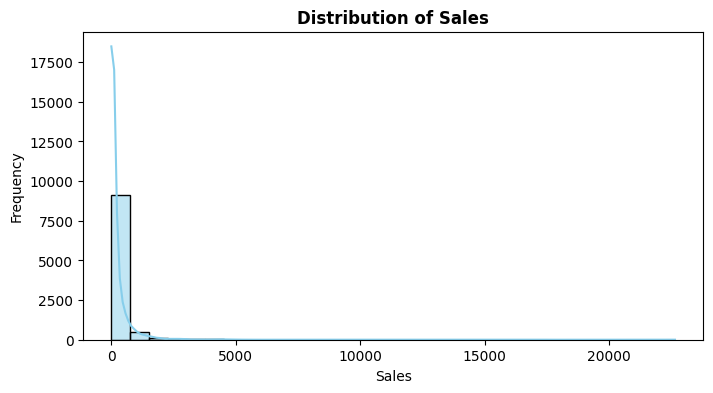

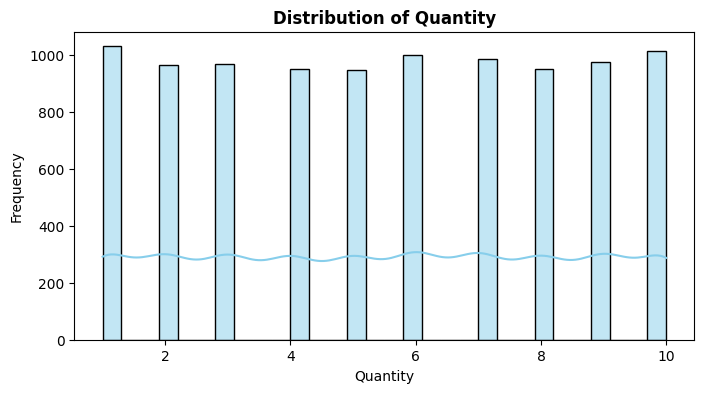

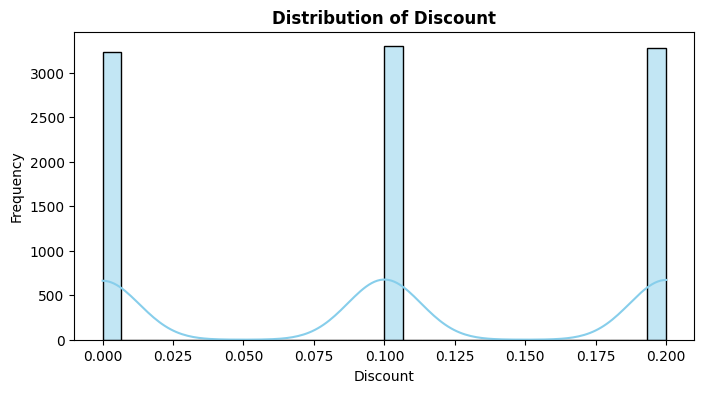

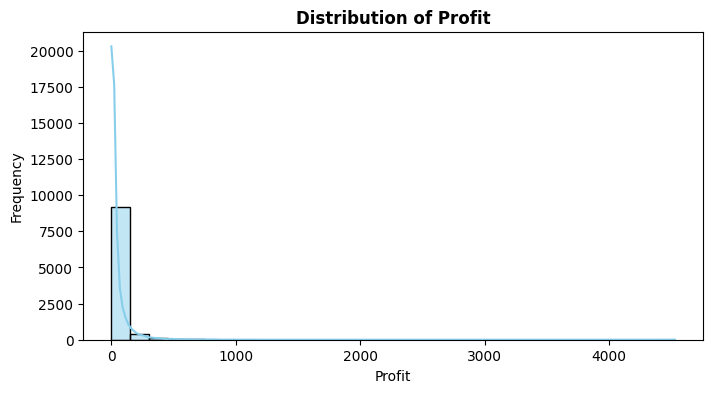

In [23]:
# Univariate Analysis (Histograms & Boxplots)
# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# 1. Histograms with KDE (Kernel Density Estimation)
for col in num_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],kde=True, bins=30, color='skyblue')
  plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

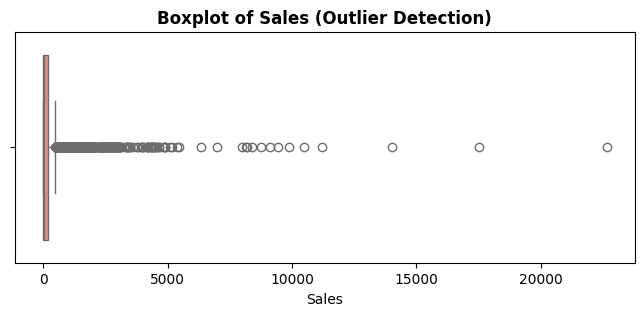

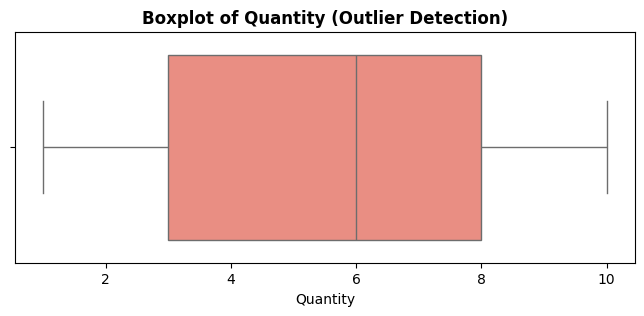

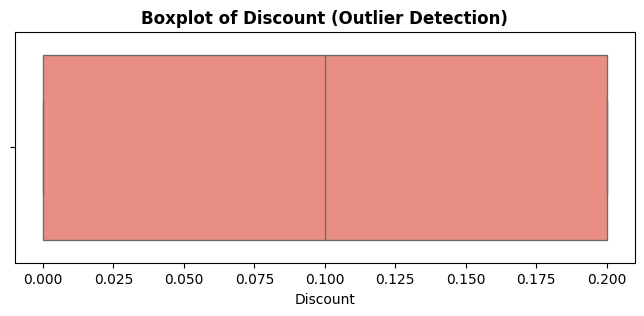

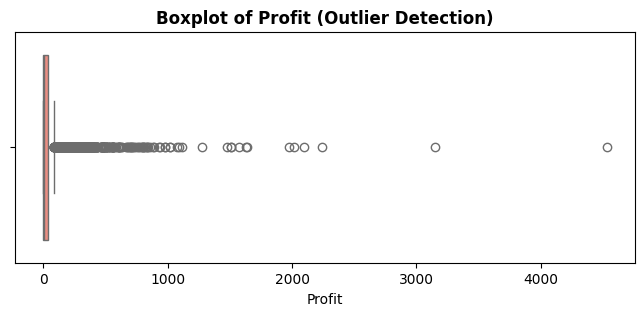

In [24]:
# 2. Boxplots to identify outliers
for col in num_cols:
  plt.figure(figsize=(8,3))
  sns.boxplot(x=df[col],color='salmon')
  plt.title(f'Boxplot of {col} (Outlier Detection)', fontsize=12, fontweight='bold')
  plt.xlabel(col)
  plt.show()

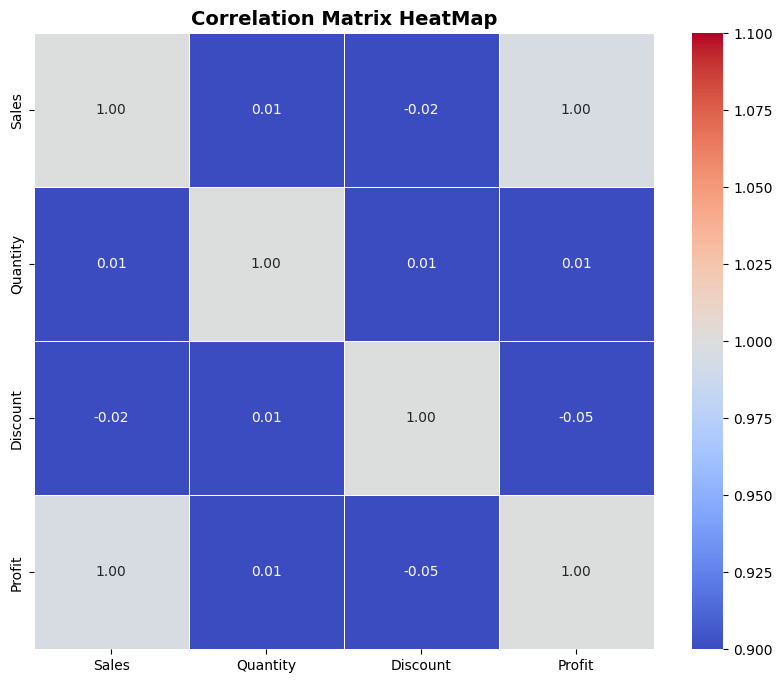

In [25]:
#Bivariate & Multivariate Analysis (Scatterplots, Heatmap, Pairplot)
# 1. Correlation Heatmap
plt.figure(figsize=(10,8))
corr_matrix= df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix HeatMap', fontsize=14, fontweight='bold')
plt.show()

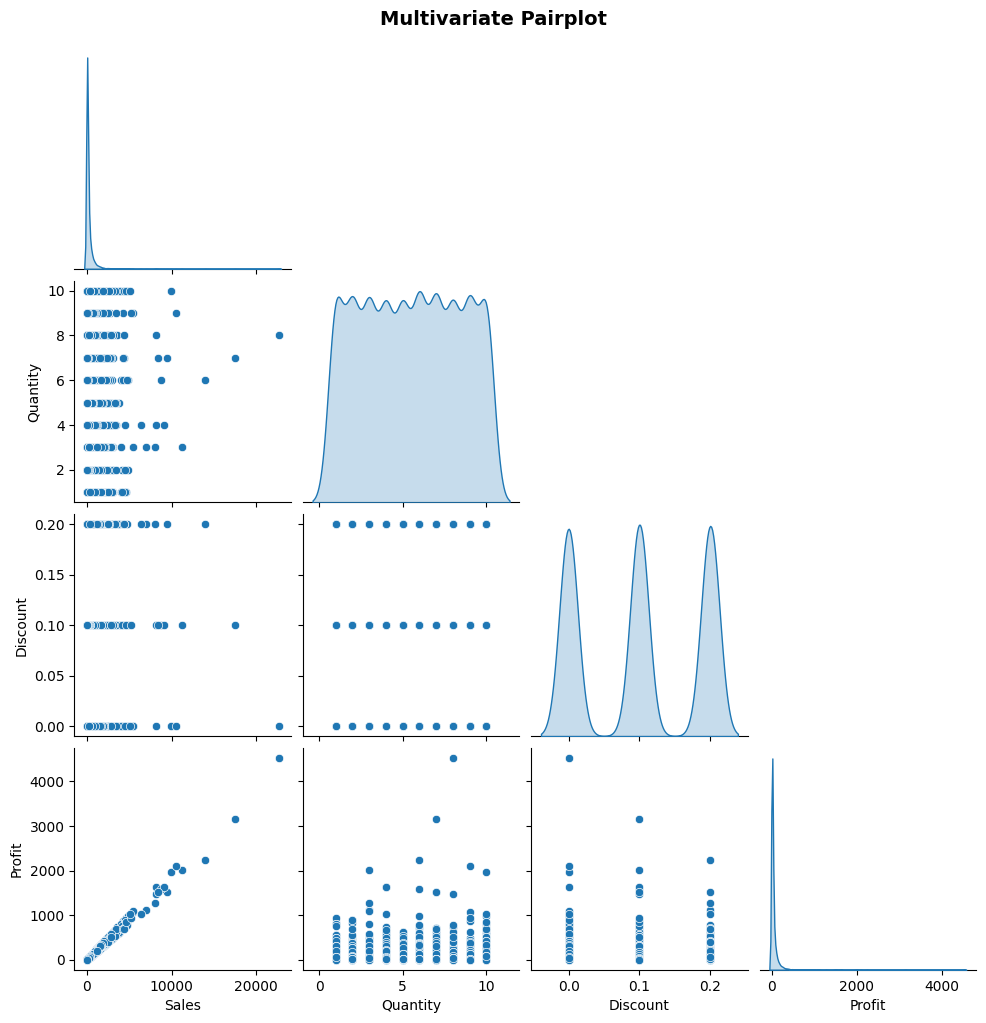

In [26]:
# 2. Pairplot for multivariate relationships
sns.pairplot(df[num_cols].dropna(),diag_kind='kde', corner=True)
plt.suptitle('Multivariate Pairplot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

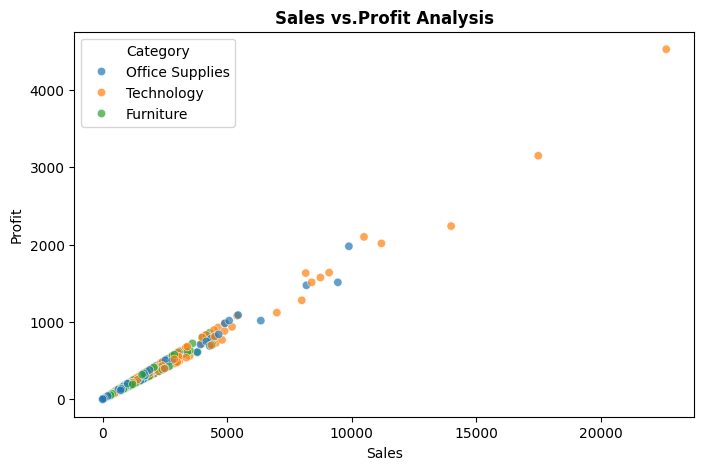

In [27]:
# 3. Targeted Bivariate Scatterplot (e.g., Sales vs Profit)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit',
                hue='Category' if 'Category' in df.columns else None,
                alpha=0.7)
plt.title('Sales vs.Profit Analysis', fontsize=12, fontweight='bold')
plt.show()

## Findings & Insights Summary

* **Distribution Patterns:** Note whether metrics (Sales, Revenue, Profit) follow normal or skewed distributions.

* **Correlations & Drivers:** Highlight strong positive correlations (e.g., Quantity sold vs. Total Revenue) or negative correlations (e.g., Higher Discount rates reducing Net Profit Margin).

* **Outliers & Anomalies:** List extreme transactions or negative profit entries requiring business investigation.